# CH 6 — Data-Mining Bias as a Function of Universe Size

## Univers de règles à mérite variable

> **Idée centrale :** le danger principal du minage de données ne vient pas seulement du nombre de règles testées, mais surtout du rapport entre le **nombre d'observations disponibles** et le **nombre de règles candidates**.

Dans cette section, on étudie un cas plus réaliste que l'univers de règles sans mérite : certaines règles ont un vrai pouvoir prédictif, d'autres non.

Cela change profondément l'interprétation.

Tester beaucoup de règles peut être dangereux sur un petit historique, mais peut devenir rationnel sur un grand historique, car on augmente les chances de découvrir une règle réellement meilleure.

## 1. Le problème EBTA

Quand on teste plusieurs règles de trading, on finit presque toujours par trouver une règle qui semble excellente dans le **backtest**.

Mais cette excellence observée peut venir de deux sources :

| Source de performance | Nature | Se répète dans le futur ? |
|---|---:|---:|
| **Mérite réel** | Pouvoir prédictif de la règle | Oui, en moyenne |
| **Chance historique** | Bruit favorable dans l'échantillon | Non |

La performance observée peut être représentée ainsi :

$$
P_{obs} = P_{real} + H
$$

où :

- $P_{obs}$ est la performance observée dans le **backtest** ;
- $P_{real}$ est le **mérite réel** de la règle ;
- $H$ est la composante de hasard liée à l'échantillon.

Le **biais de minage de données** apparaît parce que l'on sélectionne la règle avec le meilleur $P_{obs}$.

Autrement dit, on ne sélectionne pas seulement la meilleure règle.

On sélectionne souvent la règle qui combine un bon mérite réel et une chance historique favorable.

## 2. L'intuition simple

Imagine un concours de tireurs.

Si chaque tireur ne tire que **2 balles**, un débutant chanceux peut battre un champion.

Si chaque tireur tire **1 000 balles**, la chance se dilue et le vrai niveau apparaît.

En trading, c'est pareil :

- **2 observations** : le hasard domine ;
- **100 observations** : le mérite commence à apparaître ;
- **1 000 observations** : le hasard devient beaucoup moins dangereux.

> **Conclusion EBTA :** plus l'échantillon est grand, plus le minage de données devient capable d'identifier le vrai mérite au lieu de sélectionner un mirage statistique.

## 3. Simulation Python

Nous allons simuler un univers de règles de trading.

Chaque règle possède un **mérite réel** différent.

Ensuite, pour chaque règle, on observe une performance historique bruitée par le hasard.

Le processus de data mining sélectionne la règle avec la meilleure performance observée.

Puis on mesure le biais :

$$
	ext{Biais} = P_{obs, gagnant} - P_{real, gagnant}
$$

Et en pourcentage :

$$
	ext{Biais \%} = \frac{P_{obs, gagnant} - P_{real, gagnant}}{|P_{real, gagnant}|} \times 100
$$

Dans la simulation, nous allons comparer plusieurs tailles d'historique :

- $n = 2$ observations ;
- $n = 100$ observations ;
- $n = 1000$ observations.

Puis plusieurs tailles d'univers :

$$
M \in \{1, 2, 4, 8, 16, 32, 64, 128, 256\}
$$

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_data_mining_bias(
    universe_sizes,
    sample_sizes,
    n_simulations=5_000,
    merit_mean=0.01,
    merit_std=0.01,
    noise_std=0.05
):
    """
    Simule le biais de minage dans un univers de règles à mérite variable.

    Chaque règle a un mérite réel tiré d'une distribution normale.
    La performance observée ajoute une erreur d'échantillonnage qui diminue avec la taille de l'historique.

    Parameters
    ----------
    universe_sizes : list[int]
        Nombre de règles testées.
    sample_sizes : list[int]
        Nombre d'observations historiques disponibles.
    n_simulations : int
        Nombre de répétitions Monte Carlo.
    merit_mean : float
        Mérite moyen réel des règles.
    merit_std : float
        Dispersion du mérite réel entre règles.
    noise_std : float
        Bruit d'une observation individuelle.

    Returns
    -------
    pd.DataFrame
        Résultats moyens par taille d'univers et taille d'échantillon.
    """

    rows = []

    for n_obs in sample_sizes:
        standard_error = noise_std / np.sqrt(n_obs)

        for m_rules in universe_sizes:
            biases = []
            observed_winners = []
            true_merit_winners = []
            best_true_merits = []

            for _ in range(n_simulations):
                true_merits = np.random.normal(
                    loc=merit_mean,
                    scale=merit_std,
                    size=m_rules
                )

                observed_performances = true_merits + np.random.normal(
                    loc=0,
                    scale=standard_error,
                    size=m_rules
                )

                winner_idx = np.argmax(observed_performances)

                observed_winner = observed_performances[winner_idx]
                true_merit_winner = true_merits[winner_idx]
                best_true_merit = np.max(true_merits)

                bias = observed_winner - true_merit_winner

                biases.append(bias)
                observed_winners.append(observed_winner)
                true_merit_winners.append(true_merit_winner)
                best_true_merits.append(best_true_merit)

            mean_bias = np.mean(biases)
            mean_observed_winner = np.mean(observed_winners)
            mean_true_merit_winner = np.mean(true_merit_winners)
            mean_best_true_merit = np.mean(best_true_merits)

            bias_pct = mean_bias / abs(mean_true_merit_winner) * 100

            rows.append({
                "observations": n_obs,
                "rules_tested": m_rules,
                "mean_bias": mean_bias,
                "bias_pct": bias_pct,
                "mean_observed_winner": mean_observed_winner,
                "mean_true_merit_winner": mean_true_merit_winner,
                "mean_best_true_merit_available": mean_best_true_merit
            })

    return pd.DataFrame(rows)


universe_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
sample_sizes = [2, 100, 1000]

results = simulate_data_mining_bias(
    universe_sizes=universe_sizes,
    sample_sizes=sample_sizes
)

results.head()

,observations,rules_tested,mean_bias,bias_pct,mean_observed_winner,mean_true_merit_winner,mean_best_true_merit_available
0,2,1,0.000018,0.182265,0.009970,0.009952,0.009952
1,2,2,0.018894,162.068357,0.030553,0.011658,0.015619
2,2,4,0.035299,275.191926,0.048126,0.012827,0.020349
3,2,8,0.048868,352.704381,0.062724,0.013855,0.024214
4,2,16,0.059754,399.624436,0.074706,0.014952,0.027602


## 4. Lecture du tableau

Le tableau contient plusieurs colonnes importantes :

| Colonne | Signification |
|---|---|
| `observations` | Nombre d'observations historiques utilisées |
| `rules_tested` | Nombre de règles testées |
| `mean_bias` | Biais moyen de sélection |
| `bias_pct` | Biais moyen en pourcentage du mérite réel sélectionné |
| `mean_observed_winner` | Performance moyenne observée de la règle gagnante |
| `mean_true_merit_winner` | Mérite réel moyen de la règle gagnante |
| `mean_best_true_merit_available` | Meilleur mérite réel disponible dans l'univers |

La colonne la plus importante pour comprendre le danger du minage est `bias_pct`.

Plus elle est élevée, plus le backtest surestime la réalité.

In [7]:
summary = results.pivot(
    index="rules_tested",
    columns="observations",
    values="bias_pct"
).round(2)

summary

observations,2,100,1000
rules_tested,,,
1,0.18,-0.82,-0.07
2,162.07,9.43,0.90
4,275.19,12.11,1.24
8,352.70,14.50,1.44
16,399.62,15.43,1.47
32,454.29,16.21,1.70
64,487.92,16.73,1.74
128,516.75,17.56,1.66
256,545.14,17.59,1.75


## 5. Graphique : le biais selon la taille de l'univers

Ici, on regarde comment le **biais de minage** évolue quand on teste de plus en plus de règles.

Le point essentiel à observer :

- avec $n = 2$, le biais explose ;
- avec $n = 100$, le biais devient beaucoup plus contrôlé ;
- avec $n = 1000$, le biais devient faible ;
- après environ 30 règles, la courbe tend à s'aplatir.

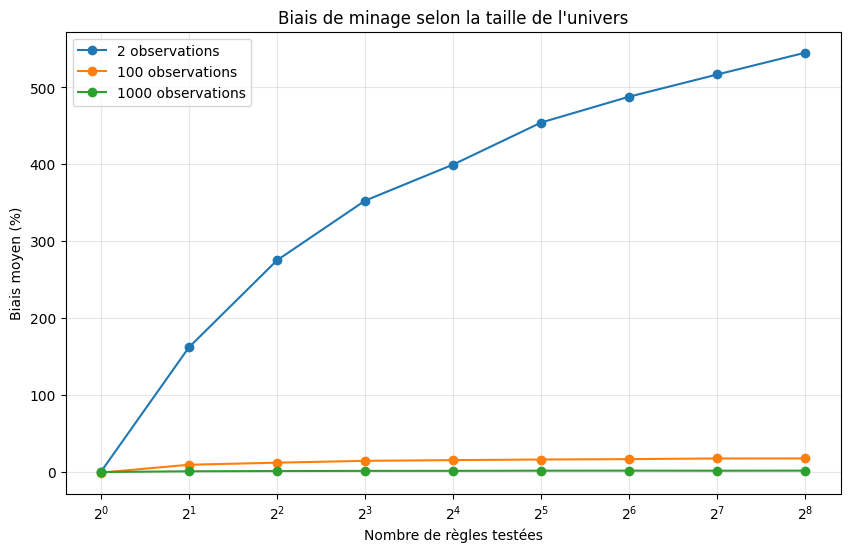

In [8]:
plt.figure(figsize=(10, 6))

for n_obs in sample_sizes:
    subset = results[results["observations"] == n_obs]
    plt.plot(
        subset["rules_tested"],
        subset["bias_pct"],
        marker="o",
        label=f"{n_obs} observations"
    )

plt.xscale("log", base=2)
plt.xlabel("Nombre de règles testées")
plt.ylabel("Biais moyen (%)")
plt.title("Biais de minage selon la taille de l'univers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Pourquoi le biais plafonne ?

Quand on teste plus de règles, on donne plus d'occasions au hasard de produire une performance exceptionnellement favorable.

Mais cet effet n'augmente pas linéairement.

Passer de 1 à 30 règles change beaucoup la sélection.

Passer de 30 à 256 règles change moins le niveau du biais, surtout si l'échantillon est large.

La raison intuitive est que les valeurs extrêmes du hasard deviennent de plus en plus rares.

> **Eurêka :** le hasard a un plafond pratique. Après un certain nombre de tests, ajouter des règles augmente encore les chances de trouver du vrai mérite, mais augmente de moins en moins le biais supplémentaire.

In [9]:
# Mesurons le biais additionnel entre 32 et 256 règles.

bias_32 = results[results["rules_tested"] == 32][["observations", "bias_pct"]].rename(
    columns={"bias_pct": "bias_pct_32_rules"}
)

bias_256 = results[results["rules_tested"] == 256][["observations", "bias_pct"]].rename(
    columns={"bias_pct": "bias_pct_256_rules"}
)

comparison = bias_32.merge(bias_256, on="observations")
comparison["additional_bias_from_32_to_256"] = (
    comparison["bias_pct_256_rules"] - comparison["bias_pct_32_rules"]
)

comparison.round(2)

,observations,bias_pct_32_rules,bias_pct_256_rules,additional_bias_from_32_to_256
0,2,454.29,545.14,90.86
1,100,16.21,17.59,1.38
2,1000,1.70,1.75,0.06


## 7. Graphique : performance observée vs mérite réel

Ce graphique compare :

- la performance observée de la règle gagnante ;
- le mérite réel de cette règle ;
- le meilleur mérite réel réellement disponible dans l'univers.

La différence entre la performance observée et le mérite réel sélectionné représente le **biais de data mining**.

La différence entre le mérite réel sélectionné et le meilleur mérite disponible montre si le processus de sélection arrive à identifier une bonne règle ou s'il choisit surtout un coup de chance.

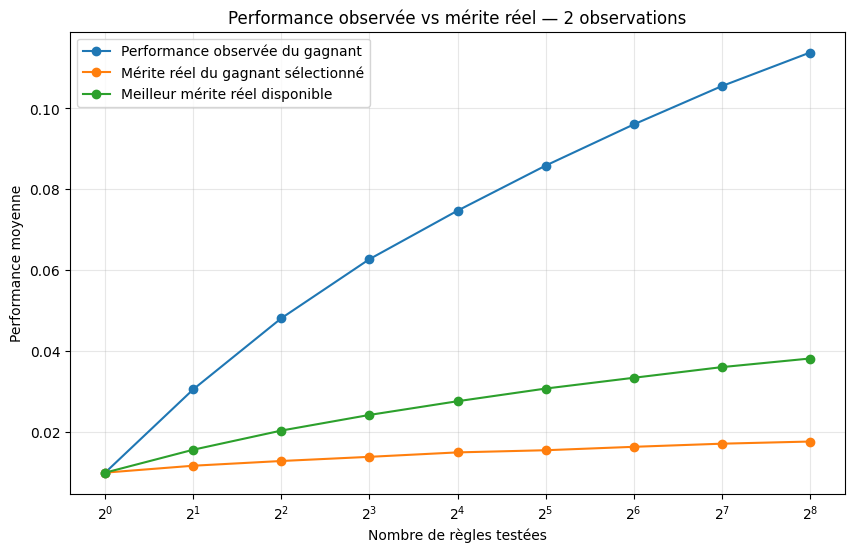

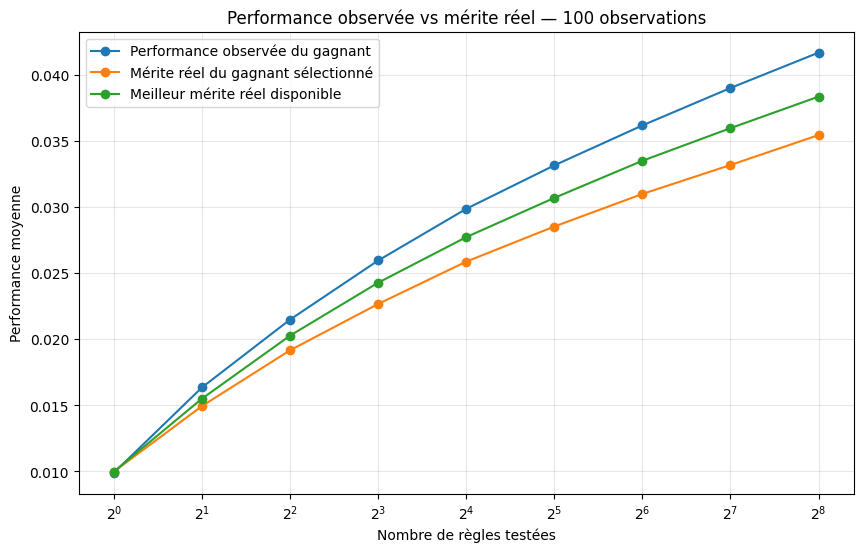

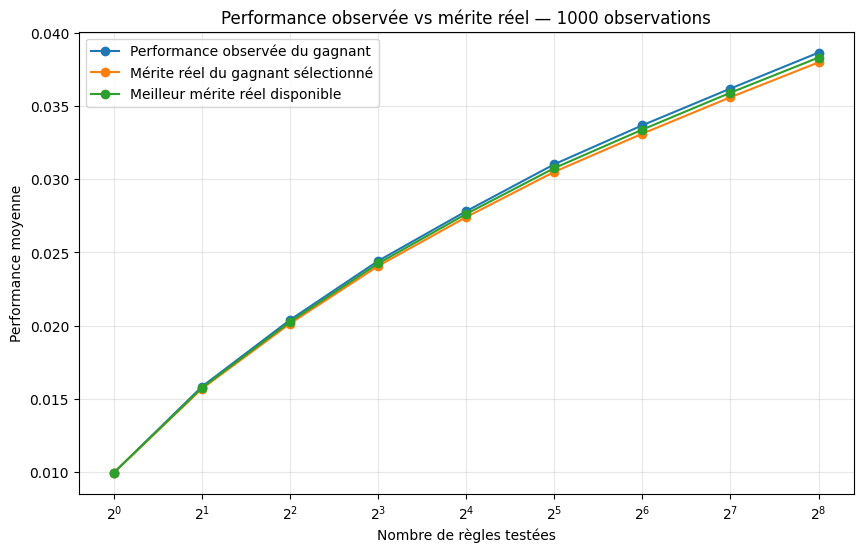

In [10]:
for n_obs in sample_sizes:
    subset = results[results["observations"] == n_obs]

    plt.figure(figsize=(10, 6))
    plt.plot(
        subset["rules_tested"],
        subset["mean_observed_winner"],
        marker="o",
        label="Performance observée du gagnant"
    )
    plt.plot(
        subset["rules_tested"],
        subset["mean_true_merit_winner"],
        marker="o",
        label="Mérite réel du gagnant sélectionné"
    )
    plt.plot(
        subset["rules_tested"],
        subset["mean_best_true_merit_available"],
        marker="o",
        label="Meilleur mérite réel disponible"
    )

    plt.xscale("log", base=2)
    plt.xlabel("Nombre de règles testées")
    plt.ylabel("Performance moyenne")
    plt.title(f"Performance observée vs mérite réel — {n_obs} observations")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 8. Interprétation trading

Dans un **backtest court**, tester beaucoup de règles revient à organiser un concours de chance.

La règle gagnante est probablement celle qui a capturé le meilleur accident historique.

Dans un **backtest long**, la chance se dilue.

La règle gagnante est plus probablement une règle qui possède un vrai mérite.

Cela ne veut pas dire qu'il faut miner les données sans contrôle.

Cela veut dire que le nombre de règles testées doit toujours être interprété avec la taille de l'échantillon.

$$
	ext{Danger réel} \approx \frac{\text{Nombre de règles testées}}{\text{Nombre d'observations utiles}}
$$

Mais cette formule est une intuition, pas une loi exacte.

Le message EBTA est plus subtil :

> Le nombre de règles n'est pas mauvais en soi. Il devient dangereux quand l'historique est trop court pour distinguer le mérite réel du bruit.

## 9. Application EBTA à ton workflow de backtest

Pour un trader algorithmique, cette section donne une règle de conduite très pratique.

| Situation | Interprétation | Décision EBTA |
|---|---|---|
| Peu d'observations, beaucoup de règles | Biais énorme | Ne pas faire confiance au gagnant |
| Beaucoup d'observations, peu de règles | Biais faible | Test raisonnable |
| Beaucoup d'observations, beaucoup de règles | Biais contrôlable | Minage utile si validation correcte |
| Peu d'observations, peu de règles | Incertitude élevée | Prudence, IC large |

Dans ton pipeline EBTA, cela veut dire :

- ne pas paniquer parce qu'on teste 100 variantes ;
- paniquer si on teste 100 variantes sur un historique pauvre ;
- toujours séparer **recherche**, **validation**, **out-of-sample** et **walk-forward** ;
- toujours corriger l'enthousiasme du meilleur backtest par une estimation du biais.

## 10. Mini-checklist opérationnelle

Avant de croire une stratégie gagnante issue d'un minage :

- Ai-je assez d'observations indépendantes ?
- Combien de variantes ai-je réellement testées ?
- La performance gagnante est-elle très supérieure aux autres ou juste légèrement meilleure ?
- La règle a-t-elle une logique économique ou microstructurelle ?
- Le résultat tient-il sur un segment **out-of-sample** ?
- Le résultat tient-il après coûts, spread, slippage et latence ?
- La règle reste-t-elle robuste quand je change légèrement les paramètres ?

> **Règle de champion EBTA :** ne tombe pas amoureux du meilleur backtest. Demande toujours combien de chance il contient.

## 11. L'Eurêka final

> Le minage de données n'est pas l'ennemi.

> L'ennemi, c'est le minage de données sur un échantillon trop court.

Quand le nombre d'observations est insuffisant, le data mining transforme la chance en illusion de compétence.

Quand le nombre d'observations est suffisant, le data mining peut devenir un outil rationnel pour découvrir des règles de haut mérite.

La question centrale n'est donc pas :

> “Combien de règles ai-je testées ?”

La vraie question est :

> “Mon historique est-il assez riche pour que le mérite réel survive au bruit ?”

## 12. Annexe — Source originale collée

### **CH 6 : DATA-MINING BIAS AS A FUNCTION OF UNIVERSE SIZE: IN A UNIVERSE OF VARIABLE MERIT**

Cette section explore comment l'ampleur du biais de minage de données évolue en fonction du nombre de règles testées dans un contexte réaliste où certaines règles possèdent un véritable pouvoir prédictif (mérite variable).

#### **Idées clés :**
*   **Impact massif de l'échantillon :** La taille de l'historique (nombre d'observations) est le facteur dominant qui détermine si le biais sera gérable ou catastrophique.
*   **Biais extrême sur échantillon court :** Avec seulement deux mois de données, le biais de minage peut faire surévaluer le profit annuel de plus de 200 %.
*   **Stabilisation rapide :** Lorsque l'échantillon est suffisant (ex: 100 ou 1 000 mois), le biais cesse de croître de manière significative après que l'on a testé environ 30 règles.
*   **Le paradoxe du minage extensif :** Tester davantage de règles (passer de 30 à 250) augmente peu le biais si les données sont abondantes, mais augmente les chances de trouver une règle de haut mérite.

#### **Référence :**
*Data-Mining Bias as a Function of Universe Size: In a Universe of Variable Merit* (Pages 311–314).

#### **Citation Directe :**
« For short performance histories, the data-mining bias is extreme. [...] After approximately 30 ATRs have been examined, increasing the number tested has a minimal effect on the size of the data-mining bias. » (Pages 312 et 314).

---

#### **Vision Macro :**
L'enjeu est de lever la peur du "nombre de tests" au profit de la "qualité des données". David Aronson démontre que, contrairement à une idée reçue, tester des milliers de règles n'est pas forcément suicidaire si l'on dispose d'un historique très long. Dans un univers où le talent existe (mérite variable), le minage de données intensif devient une stratégie gagnante car le coût statistique (l'augmentation du biais) plafonne rapidement, alors que le bénéfice potentiel (trouver une règle exceptionnelle) continue de croître.

---

#### **Vision Micro :**

1.  **L'Expérience avec 2 observations (Figure 6.44) :**
    *   Sur un historique de seulement deux mois, le processus de sélection est "aveugle" au mérite réel.
    *   Le biais explose : pour 256 règles testées, le profit affiché est gonflé de **200 %** par rapport à la réalité. Ici, le minage ne produit que du « métal des fous ».

2.  **L'Expérience avec 100 et 1 000 observations (Figures 6.45 & 6.46) :**
    *   **À 100 mois :** Le biais pour 256 règles tombe à environ **18 %**.
    *   **À 1,000 mois :** Le biais est réduit à moins de **3 %**.
    *   **Convergence :** Les courbes montrent que le biais augmente fortement entre 1 et 30 règles, puis s'aplatit.

3.  **Le seuil de 30 règles (Figure 6.48) :**
    *   Aronson identifie un point d'inflexion : après 30 tentatives, la "cloche" du hasard a déjà produit ses effets les plus probables.
    *   Au-delà de ce seuil, le "prix" à payer en termes de biais supplémentaire pour chaque nouvelle règle testée devient marginal.

---

#### **Résumé Simplifié :**
Imaginez que vous cherchiez un champion de tir. Si vous ne regardez qu'un seul tir (échantillon faible), tester 200 tireurs va forcément vous faire choisir un chanceux qui a touché le centre par accident (biais énorme). Mais si vous regardez 1 000 tirs par personne, tester 200 candidats au lieu de 30 ne vous trompera pas beaucoup plus, mais vous donnera beaucoup plus de chances de débusquer le véritable champion olympique caché dans la foule.

---

#### **Actions Concrètes :**
*   **Prioriser le "N" (Observations) sur le "N" (Règles) :** Ne vous limitez pas arbitrairement à tester 5 ou 10 règles si vous avez 20 ans de données ; vous pouvez en tester des centaines sans que le biais ne devienne incontrôlable.
*   **Seuil de méfiance automatique :** Si votre historique de backtest est court (moins de 2-3 ans de données mensuelles), considérez que n'importe quel profit affiché est une illusion totale.
*   **Exploiter le plafonnement du biais :** Une fois que vous avez optimisé une trentaine de variantes, sachez que continuer l'optimisation ne dégradera plus beaucoup la fiabilité de votre estimation, à condition d'utiliser un échantillon large.

---

#### **À retenir absolument :**
*   L'échantillon court rend le minage de données **dangereux et inutile**.
*   Le biais de minage **plafonne (se stabilise)** après environ 30 règles testées.
*   Sur un échantillon large, le biais est **étonnamment faible** (ex: < 3% sur 1000 mois).
*   Tester plus de règles est une **bonne chose** si, et seulement si, l'échantillon est suffisant.
*   Le **nombre d'observations** est le véritable juge de paix de la validité EBTA.

J'ai terminé l'analyse de l'impact de la taille de l'univers de recherche sur le biais de minage selon le protocole EBTA.